In [4]:
# Core Python imports
import os, sys
from pathlib import Path
import json

# Scientific standard imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import functools
sys.path.append("/home/548/cd3022/repos/CPDiT/")
import src.prep as prep

# PyEarthTools imports including NCI cached data
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
from pyearthtools.data.time import Petdt

my_site = 'site_archive_nci'  # set this to 'site_archive_nci', 'site_archive_jasmin' or 'site_archive_met_office'
import importlib
_ = importlib.import_module(my_site)

from dask.distributed import Client

import warnings
warnings.filterwarnings("ignore",message="In a future version of xarray the default value for join",category=FutureWarning)
warnings.filterwarnings("ignore",message="In a future version of xarray the default value for compat",category=FutureWarning)
warnings.filterwarnings("ignore",message="Data requested at a higher resolution than available")
warnings.filterwarnings("ignore",message="Importing `spectral_angle_mapper` from `torchmetrics.functional`",category=FutureWarning)
warnings.filterwarnings("ignore",message="In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None",category=FutureWarning)
warnings.filterwarnings("ignore",message="IndexWarning: Data requested at a higher resolution than available. minute > hour",)

In [30]:
# We specify the date, hour, and minute for querying data
date = '20200105T0000'
start_date = '20200101T0000'
end_date = '20210101T0000'
bar_timestep = "1 hour" 
sat_timestep = "10 min" 
save_dir = Path("/scratch/er8/cd3022/CPDiT/stats/")

sat_mean_path = save_dir / "mean_sat.npy"
sat_std_path = save_dir / "std_sat.npy"
bar_mean_path = save_dir / "mean_bar.npy"
bar_std_path = save_dir / "std_bar.npy"

iterator = petpipe.iterators.DateRange(start_date, end_date, interval=bar_timestep)
iterator_full = petpipe.iterators.DateRange(start_date, end_date, interval=sat_timestep)

In [5]:
client = Client(
    n_workers=24,
    threads_per_worker=1
)

# Load sample data

In [10]:
date = "2020-01"
lat_min, lat_max, lon_min, lon_max = -35, -28.5, 145, 151.5
him_vars = [
    "surface_global_irradiance",
    "solar_elevation"
]
bar_std = ["tas"]
bar_conv = [
    "RH24mean"
]
him = prep.get_heliosat(
    date,
    variables=him_vars,
    lat_min=lat_min,
    lat_max=lat_max,
    lon_min=lon_min,
    lon_max=lon_max
)

In [11]:
# load BARRA-R2 data
bar = prep.get_barra(
    date,
    bar_std, bar_conv,
    lat_min=lat_min,
    lat_max=lat_max,
    lon_min=lon_min,
    lon_max=lon_max
)

In [17]:
bar = bar[bar_conv]

In [22]:
stats = {}
compute=False
if compute:
    for var in him.data_vars:
        mean = him[var].mean().values.item()
        std = him[var].std().values.item()
        stats[var] = {"mean": mean, "std": std}
    for var in bar.data_vars:
        mean = bar[var].mean().values.item()
        std = bar[var].std().values.item()
        stats[var] = {"mean": mean, "std": std}
    
    with open(save_dir / "combined_stats.json", "w") as f:
        json.dump(stats, f, indent=4)

# Test the Stats

In [23]:
with open(save_dir / "combined_stats.json", "r") as f:
    stats = json.load(f)

In [27]:
n_prior_sat  = 12   # context frames
n_prior_bar  = n_prior_sat // 6
n_post       = 1

In [32]:
himawari_vars = ["surface_global_irradiance", "solar_elevation"]
himawari = petdata.archive.Himawari(himawari_vars)

barra_vars   = ["RH24mean"]
barra_domain = "AUST-11"
barra_freq   = "1hr"

barra_conv = petdata.archive.BARRA_V2(
    barra_vars,
    domain_id  = barra_domain,
    frequency  = barra_freq,
)

temporal_window_sat = petpipe.modifications.TemporalWindow(
    prior_indexes=[i for i in range(-n_prior_sat - 1, 0)],
    posterior_indexes=[i for i in range(0, n_post + 1)],
    merge_method = functools.partial(xr.concat, dim='time'),
    timedelta=petdata.time.TimeDelta((10, "minutes"))
)
sat_pipe = petpipe.Pipeline(
    himawari,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  #
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),
    petdata.transform.region.Bounding(-35, -28.5, 145, 151.5),  # cut down on region for example
    temporal_window_sat,
    petpipe.operations.xarray.Merge(),
    # iterator=petpipe.iterators.DateRange(start_date, end_date, interval=sat_timestep),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

temporal_window_bar = petpipe.modifications.TemporalWindow(
    prior_indexes=[i for i in range(-n_prior_bar - 1, 0)],
    posterior_indexes=[i for i in range(0, n_post + 1)],
    merge_method = functools.partial(xr.concat, dim='time'),
    timedelta=petdata.time.TimeDelta((1, "h"))
)

bar_pipe = petpipe.Pipeline(
    barra_conv,
    petdata.transforms.coordinates.Drop("crs"),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),
    petdata.transform.region.Bounding(-35, -28.5, 145, 151.5),  # cut down on region for example
    temporal_window_bar,
    petpipe.operations.xarray.Merge(),
    # iterator=petpipe.iterators.DateRange(start_date, end_date, interval=bar_timestep),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

full_pipe = petpipe.Pipeline(
    (sat_pipe, bar_pipe),
    iterator=iterator_full,
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)
full_iterator = iter(full_pipe)
sat_sample, bar_sample = next(full_iterator)

for var in sat_sample:
    sat_sample[var] = (sat_sample[var] - stats[var]["mean"]) / stats[var]["std"]
for var in bar_sample:
    bar_sample[var] = (bar_sample[var] - stats[var]["mean"]) / stats[var]["std"]

bar_interp = bar_sample.interp(
    latitude=sat_sample.latitude,
    longitude=sat_sample.longitude,
    time=sat_sample.time,
    method='nearest'
)
combined = xr.merge([bar_interp, sat_sample])
combined_inner = combined.isel(
    time=slice(1, -1),
    latitude=slice(10, 266),
    longitude=slice(10, 266),
)
arr = np.stack([combined_inner[v].values for v in combined_inner.data_vars], axis=0)  # (c, t, h, w)

# Rearrange c t h w -> t c h w
arr = np.transpose(arr, (1, 0, 2, 3))  # (t, c, h, w)

In [34]:
arr.shape

(13, 3, 256, 256)

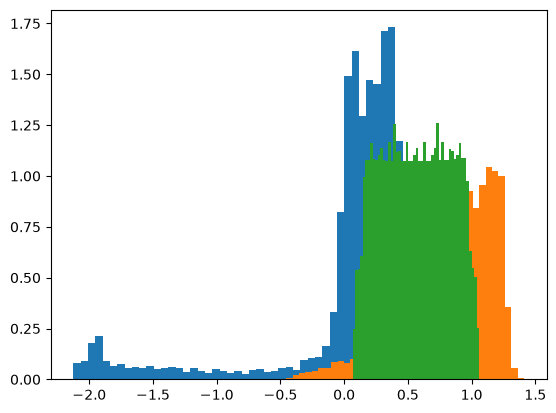

In [35]:
for c in range(arr.shape[1]):
    data = arr[:,c,:,:].ravel()
    plt.hist(data, bins=50, density=True)

In [37]:
arr.shape

(13, 3, 256, 256)

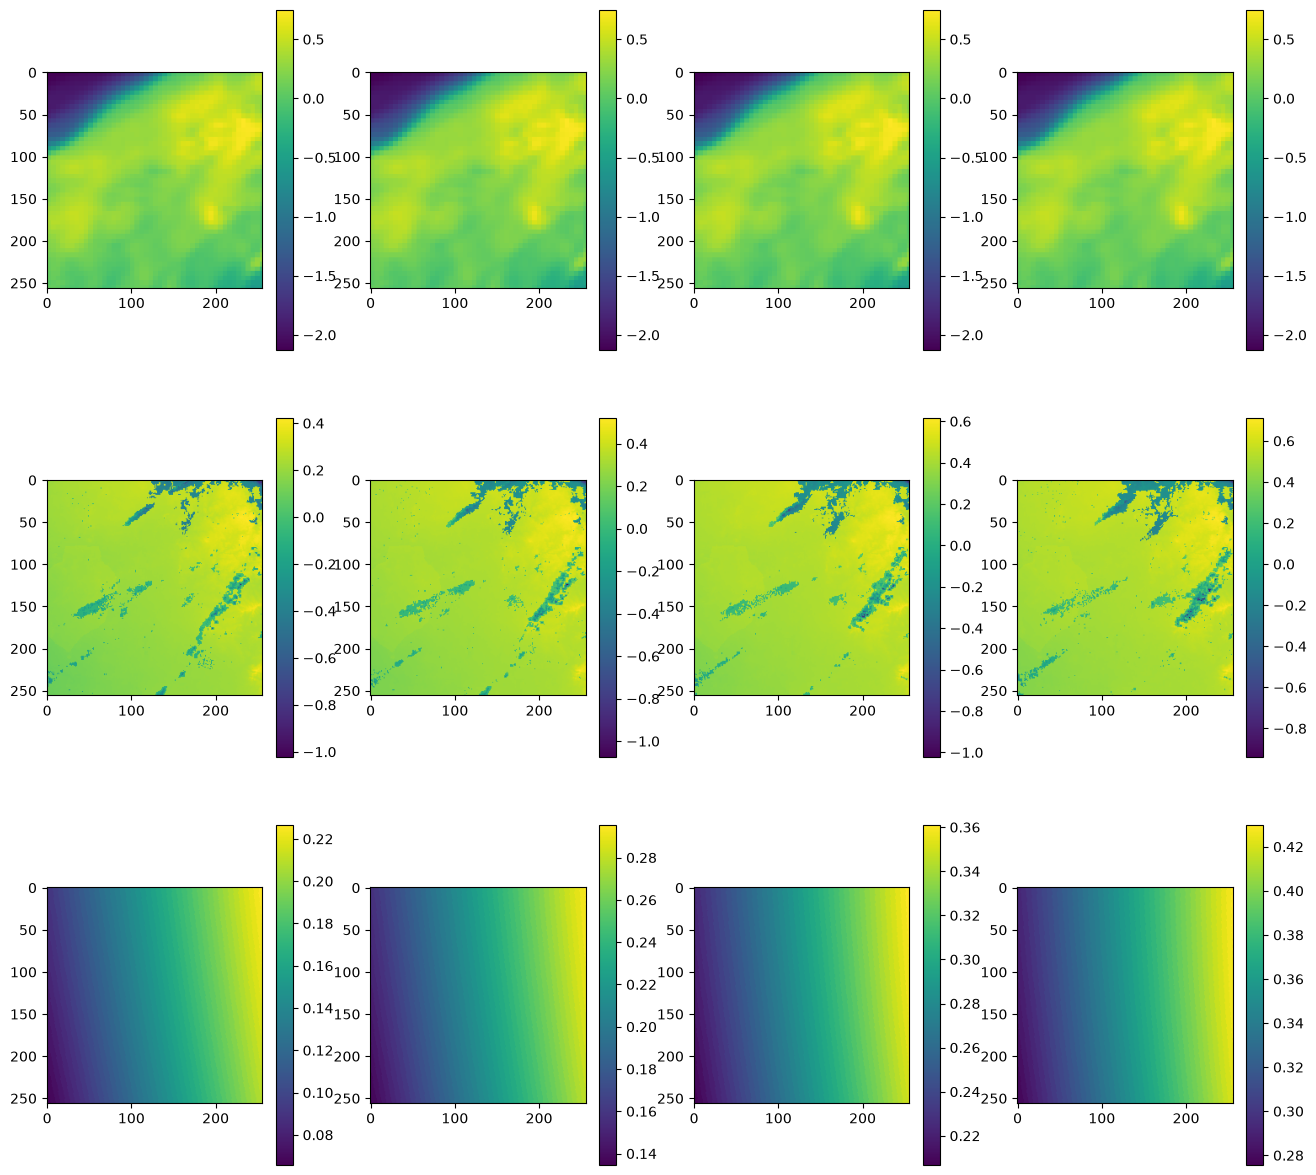

In [39]:
nrows = arr.shape[1]
ncols = np.min([arr.shape[0], 4])
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*5))
for i in range(nrows):
    for j in range(ncols):
        im = ax[i,j].imshow(arr[j,i,:,:])
        fig.colorbar(im, ax=ax[i,j])

## Himawari

/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/operations/index_routines.py:209: IndexWarning: Unable to subset on time dimension, returning all timesteps for validation. For request: 2020-01-05T00:00 -> 2020-01-06T00:00 @ 0 days 00:10:00
  warnings.warn(


(array([0.24004137, 0.18196423, 0.21554514, 0.2041352 , 0.14292168,
        0.18683103, 0.20797457, 0.16774236, 0.27519047, 0.287736  ,
        0.30677059, 0.3167205 , 0.32039763, 0.35149107, 0.31423302,
        0.32007318, 0.29860519, 0.29222427, 0.29200797, 0.28146324,
        0.28130101, 0.28130101, 0.28130101, 0.28130101, 0.28130101,
        0.28130101, 0.2855189 , 0.2800032 , 0.2926028 , 0.2782187 ,
        0.27713719, 0.29308948, 0.27627198, 0.27643421, 0.2923865 ,
        0.27654236, 0.29319763, 0.2773535 , 0.27848908, 0.29644216,
        0.28184177, 0.28459962, 0.30471572, 0.29346801, 0.3222362 ,
        0.31969465, 0.33840479, 0.34673243, 0.28011135, 0.70898454]),
 array([-1.43222454, -1.3625204 , -1.29281627, -1.22311214, -1.15340801,
        -1.08370387, -1.01399974, -0.94429561, -0.87459147, -0.80488734,
        -0.73518321, -0.66547907, -0.59577494, -0.52607081, -0.45636667,
        -0.38666254, -0.31695841, -0.24725427, -0.17755014, -0.10784601,
        -0.03814187,  0.03

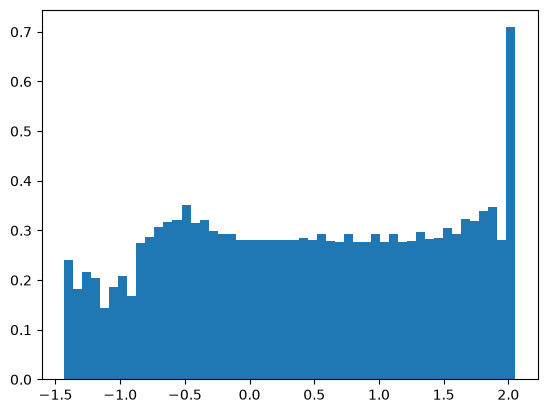

In [32]:
sat_normed_samples = sat_pipe_normed["20200105"]

flat_sat_v1 = (sat_normed_samples[0,:,:,:]).ravel()
plt.hist(flat_sat_v1, bins=50, density=True)

(array([0.69429839, 0.33703197, 0.24876468, 0.25828677, 0.25177165,
        0.1770984 , 0.21625174, 0.26022878, 0.1386968 , 0.26442601,
        0.20378532, 0.15780363, 0.27018939, 0.12879884, 0.25377631,
        0.21499883, 0.17014477, 0.25872529, 0.11138343, 0.30483226,
        0.18593139, 0.21105218, 0.29299229, 0.14608895, 0.33790901,
        0.24375305, 0.17828866, 0.32945189, 0.28591337, 0.16732572,
        0.30182529, 0.26837267, 0.13205639, 0.26179491, 0.25333779,
        0.1386968 , 0.11652035, 0.22984578, 0.23479476, 0.24250014,
        0.23554651, 0.18906366, 0.32137064, 0.34505058, 0.35463532,
        0.46276119, 0.52239956, 1.0241888 , 0.69768124, 0.01735276]),
 array([-1.39171547e+00, -1.31845430e+00, -1.24519313e+00, -1.17193195e+00,
        -1.09867078e+00, -1.02540960e+00, -9.52148429e-01, -8.78887255e-01,
        -8.05626081e-01, -7.32364907e-01, -6.59103733e-01, -5.85842559e-01,
        -5.12581385e-01, -4.39320211e-01, -3.66059037e-01, -2.92797863e-01,
        -2.195

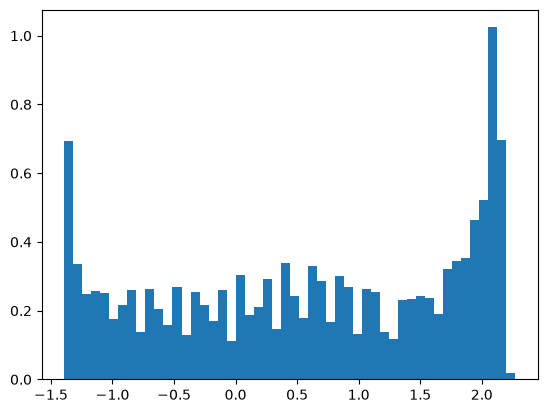

In [33]:
flat_sat_v2 = (sat_normed_samples[1,:,:,:]).ravel()
plt.hist(flat_sat_v2, bins=50, density=True)

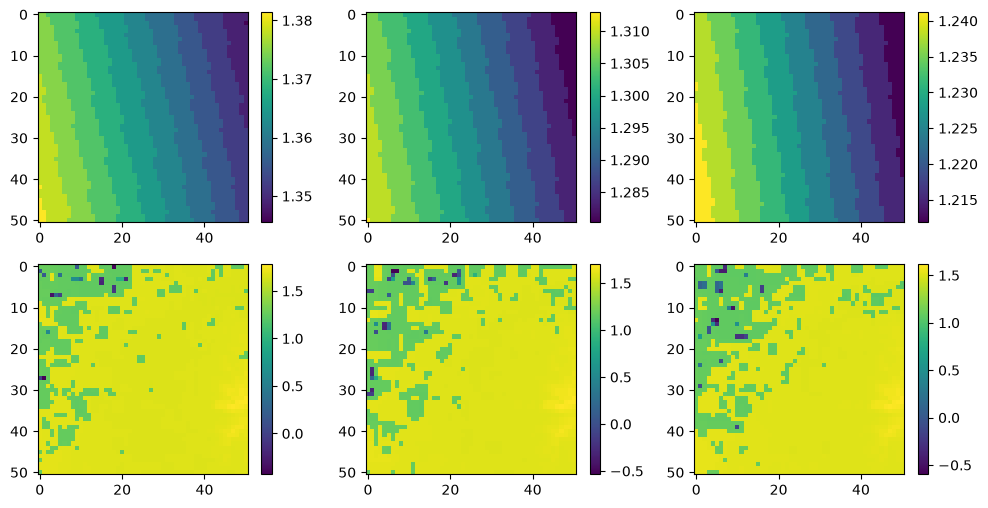

In [41]:
nrows = sat_normed_samples.shape[0]
ncols = 3 # num times to show
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*3))
for i in range (nrows):
    for j in range(ncols):
        im = ax[i,j].imshow(sat_normed_samples[i,j+25,:,:])
        fig.colorbar(im, ax=ax[i,j])